# Klasyfikator Gatunków Ptaków z TensorFlow

Transfer learning z **EfficientNetB0** do klasyfikacji **1 486 gatunków ptaków** przy użyciu czystych API TensorFlow:
- Potoki `tf.data` do wczytywania danych
- `tf.image` do augmentacji
- Niestandardowa pętla treningowa `tf.GradientTape`
- `tf.saved_model` do zapisu i wczytywania modelu

**Zbiór danych:** `birds_train_small` — 1 486 gatunków, ~140 zdjęć każdy (~208 tys. łącznie)

## 1. Importy i Konfiguracja

In [2]:
import os

# Naprawa ścieżki libdevice dla XLA (kompilacja JIT na GPU)
# XLA oczekuje: {katalog}/nvvm/libdevice/libdevice.10.bc
os.environ["XLA_FLAGS"] = "--xla_gpu_cuda_data_dir=" + os.path.join(os.getcwd(), "cuda")

import json
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

print(f"Wersja TensorFlow: {tf.__version__}")
print(f"Dostępne GPU: {tf.config.list_physical_devices('GPU')}")

2026-02-26 15:54:44.899634: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


Wersja TensorFlow: 2.20.0
Dostępne GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
# Konfiguracja
DATA_DIR = os.path.join(os.getcwd(), "archive", "birds_train_small")
CHECKPOINT_DIR = os.path.join(os.getcwd(), "checkpoints")
SAVED_MODEL_DIR = os.path.join(os.getcwd(), "saved_model")
CLASS_NAMES_PATH = os.path.join(os.getcwd(), "class_names.json")

IMG_SIZE = 224
BATCH_SIZE = 32
VALIDATION_SPLIT = 0.2
SEED = 42

INITIAL_EPOCHS = 10     # Faza 1: trenowanie tylko głowy klasyfikatora
FINE_TUNE_EPOCHS = 10   # Faza 2: dostrajanie górnych warstw szkieletu
INITIAL_LR = 1e-3
FINE_TUNE_LR = 1e-5

os.makedirs(CHECKPOINT_DIR, exist_ok=True)
print(f"Katalog danych: {DATA_DIR}")
print(f"Istnieje: {os.path.isdir(DATA_DIR)}")

Katalog danych: /media/server/BIRDS/archive/birds_train_small
Istnieje: True


## 2. Eksploracja Zbioru Danych

In [3]:
# Lista wszystkich katalogów gatunków
class_dirs = sorted([
    d for d in os.listdir(DATA_DIR)
    if os.path.isdir(os.path.join(DATA_DIR, d))
])
num_classes = len(class_dirs)

def extract_species_name(folder_name):
    """Wyodrębnia nazwę gatunku z nazwy katalogu: 'Rodzaj gatunek'."""
    parts = folder_name.split("_")
    if len(parts) >= 2:
        return f"{parts[-2]} {parts[-1]}"
    return folder_name

print(f"Liczba gatunków: {num_classes}")
print(f"\nPierwsze 10 gatunków:")
for d in class_dirs[:10]:
    n_imgs = len(os.listdir(os.path.join(DATA_DIR, d)))
    print(f"  {extract_species_name(d):<30s} ({n_imgs} zdjęć)")

Liczba gatunków: 1486

Pierwsze 10 gatunków:
  Accipiter badius               (140 zdjęć)
  Accipiter cooperii             (140 zdjęć)
  Accipiter gentilis             (140 zdjęć)
  Accipiter nisus                (140 zdjęć)
  Accipiter striatus             (140 zdjęć)
  Accipiter trivirgatus          (140 zdjęć)
  Aegypius monachus              (140 zdjęć)
  Aquila audax                   (140 zdjęć)
  Aquila chrysaetos              (140 zdjęć)
  Aquila heliaca                 (140 zdjęć)


Łączna liczba zdjęć: 208,041
Minimum na gatunek: 140
Maksimum na gatunek: 141
Średnia na gatunek: 140.0


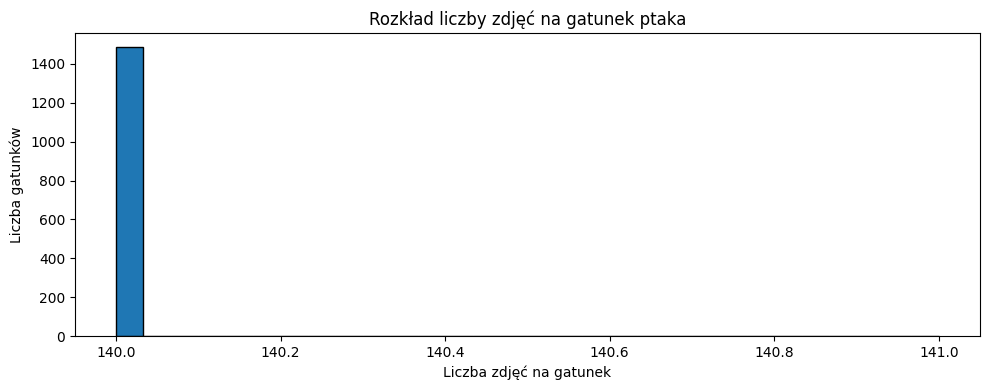

In [4]:
# Rozkład liczby zdjęć na gatunek
imgs_per_class = [len(os.listdir(os.path.join(DATA_DIR, d))) for d in class_dirs]

print(f"Łączna liczba zdjęć: {sum(imgs_per_class):,}")
print(f"Minimum na gatunek: {min(imgs_per_class)}")
print(f"Maksimum na gatunek: {max(imgs_per_class)}")
print(f"Średnia na gatunek: {np.mean(imgs_per_class):.1f}")

plt.figure(figsize=(10, 4))
plt.hist(imgs_per_class, bins=30, edgecolor="black")
plt.xlabel("Liczba zdjęć na gatunek")
plt.ylabel("Liczba gatunków")
plt.title("Rozkład liczby zdjęć na gatunek ptaka")
plt.tight_layout()
plt.show()

I0000 00:00:1771621798.587208 1542908 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 6815 MB memory:  -> device: 0, name: Quadro RTX 4000, pci bus id: 0000:01:00.0, compute capability: 7.5


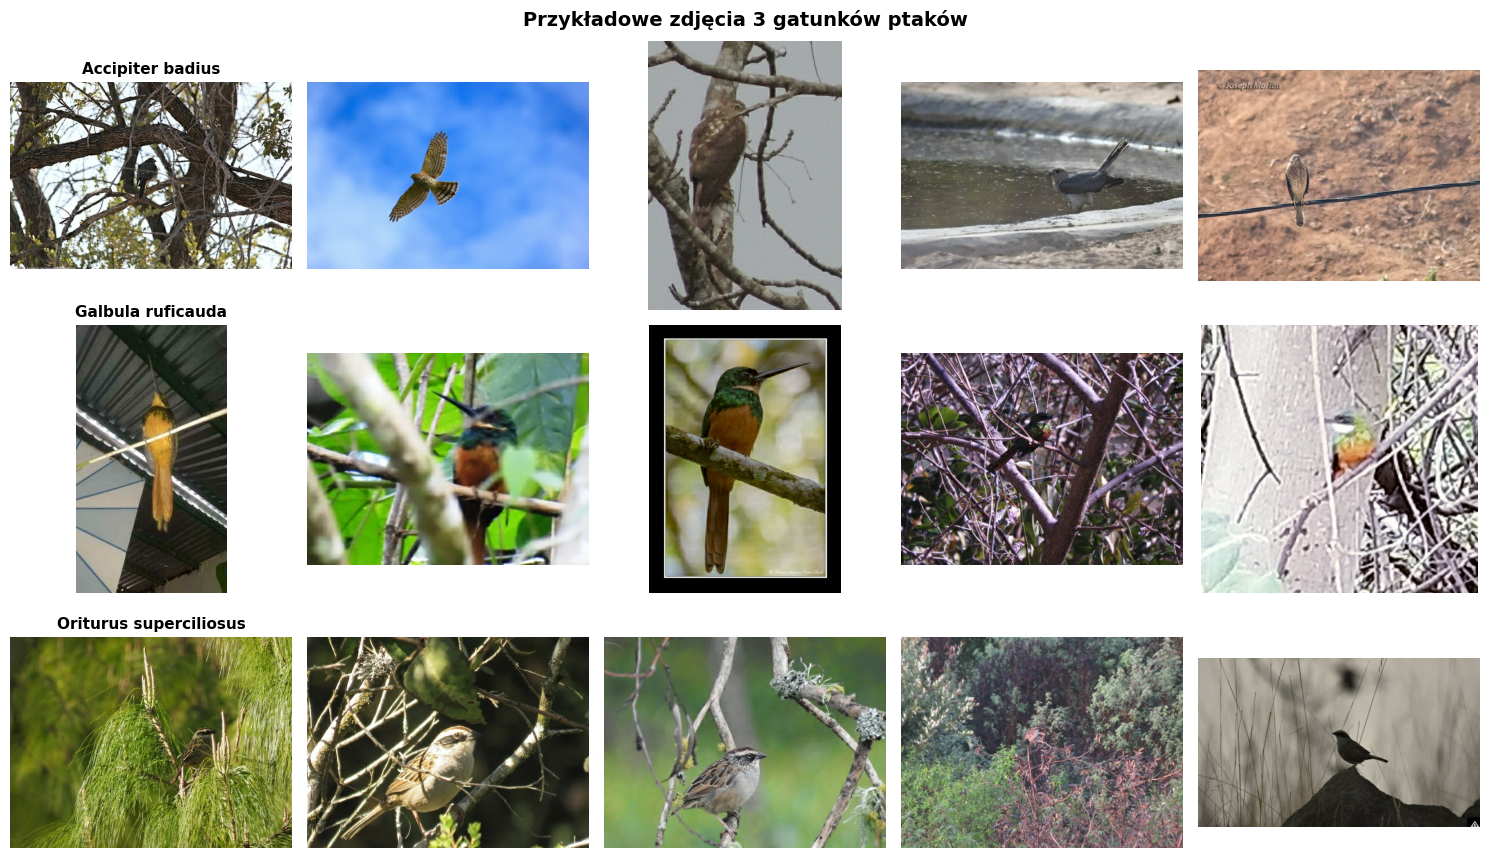

In [5]:
# Przykładowe zdjęcia z kilku gatunków
fig, axes = plt.subplots(3, 5, figsize=(15, 9))
sample_classes = class_dirs[::500][:3]  # 3 równomiernie rozłożone gatunki

for row, cls_dir in enumerate(sample_classes):
    cls_path = os.path.join(DATA_DIR, cls_dir)
    images = os.listdir(cls_path)[:5]
    species = extract_species_name(cls_dir)
    for col, img_name in enumerate(images):
        img = tf.io.read_file(os.path.join(cls_path, img_name))
        img = tf.image.decode_jpeg(img, channels=3)
        axes[row, col].imshow(img.numpy())
        axes[row, col].axis("off")
        if col == 0:
            axes[row, col].set_title(species, fontsize=11, fontweight="bold")

plt.suptitle("Przykładowe zdjęcia 3 gatunków ptaków", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

## 3. Budowa Potoku tf.data

In [6]:
# Mapowanie nazw klas na indeksy
class_to_idx = {name: i for i, name in enumerate(class_dirs)}

# Zapis czytelnej mapy gatunków (do późniejszej inferencji)
species_map = {i: extract_species_name(name) for i, name in enumerate(class_dirs)}
with open(CLASS_NAMES_PATH, "w") as f:
    json.dump(species_map, f, indent=2)
print(f"Nazwy klas zapisano do: {CLASS_NAMES_PATH}")

# Zebranie wszystkich ścieżek plików i etykiet
all_paths, all_labels = [], []
for class_name, label in class_to_idx.items():
    class_dir = os.path.join(DATA_DIR, class_name)
    for fname in os.listdir(class_dir):
        if fname.lower().endswith((".jpg", ".jpeg", ".png")):
            all_paths.append(os.path.join(class_dir, fname))
            all_labels.append(label)

total = len(all_paths)
print(f"Łącznie zebranych zdjęć: {total:,}")

Nazwy klas zapisano do: /media/server/BIRDS/class_names.json
Łącznie zebranych zdjęć: 208,040


In [7]:
# Tasowanie i podział na zbiór treningowy / walidacyjny
tf.random.set_seed(SEED)
indices = tf.random.shuffle(tf.range(total), seed=SEED)
split = int(total * (1 - VALIDATION_SPLIT))

train_idx = indices[:split]
val_idx = indices[split:]

paths_t = tf.constant(all_paths)
labels_t = tf.constant(all_labels, dtype=tf.int32)

train_paths = tf.gather(paths_t, train_idx)
train_labels = tf.gather(labels_t, train_idx)
val_paths = tf.gather(paths_t, val_idx)
val_labels = tf.gather(labels_t, val_idx)

print(f"Próbki treningowe:    {len(train_idx):,}")
print(f"Próbki walidacyjne:   {len(val_idx):,}")

Próbki treningowe:    166,432
Próbki walidacyjne:   41,608


In [8]:
# Funkcja wczytywania zdjęcia
def parse_image(file_path, label):
    """Odczytuje, dekoduje i przeskalowuje zdjęcie za pomocą tf.io / tf.image."""
    raw = tf.io.read_file(file_path)
    image = tf.image.decode_jpeg(raw, channels=3)
    image = tf.image.resize(image, [IMG_SIZE, IMG_SIZE])
    image = tf.cast(image, tf.float32)
    return image, label

# Pomocnik do obracania zdjęcia
@tf.function
def rotate_image(image, angle):
    """Obraca zdjęcie o podany kąt (w radianach) za pomocą transformacji afinicznej."""
    cos_a = tf.math.cos(angle)
    sin_a = tf.math.sin(angle)
    transform = [cos_a, -sin_a, 0.0, sin_a, cos_a, 0.0, 0.0, 0.0]
    image = tf.expand_dims(image, 0)
    image = tf.raw_ops.ImageProjectiveTransformV3(
        images=image,
        transforms=tf.expand_dims(transform, 0),
        output_shape=tf.shape(image)[1:3],
        interpolation="BILINEAR",
        fill_mode="NEAREST",
        fill_value=0.0,
    )
    return tf.squeeze(image, 0)

# Funkcja augmentacji danych
def augment(image, label):
    """Stosuje augmentację danych za pomocą operacji tf.image."""
    image = tf.image.random_flip_left_right(image)
    image = tf.image.random_brightness(image, max_delta=0.1)
    image = tf.image.random_contrast(image, lower=0.9, upper=1.1)
    image = tf.image.random_saturation(image, lower=0.9, upper=1.1)
    angle = tf.random.uniform([], -0.15, 0.15)
    image = rotate_image(image, angle)
    image = tf.clip_by_value(image, 0.0, 255.0)
    return image, label

print("Funkcje przetwarzania obrazów gotowe.")

Funkcje przetwarzania obrazów gotowe.


In [9]:
# Budowa potoków tf.data.Dataset
autotune = tf.data.AUTOTUNE

train_ds = (
    tf.data.Dataset.from_tensor_slices((train_paths, train_labels))
    .shuffle(buffer_size=min(len(train_idx), 10000), seed=SEED)
    .map(parse_image, num_parallel_calls=autotune)
    .map(augment, num_parallel_calls=autotune)
    .batch(BATCH_SIZE)
    .prefetch(autotune)
)

val_ds = (
    tf.data.Dataset.from_tensor_slices((val_paths, val_labels))
    .map(parse_image, num_parallel_calls=autotune)
    .batch(BATCH_SIZE)
    .prefetch(autotune)
)

print(f"Zbiór treningowy:    {train_ds}")
print(f"Zbiór walidacyjny:   {val_ds}")

Zbiór treningowy:    <_PrefetchDataset element_spec=(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))>
Zbiór walidacyjny:   <_PrefetchDataset element_spec=(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))>


### Wizualizacja Próbek po Augmentacji

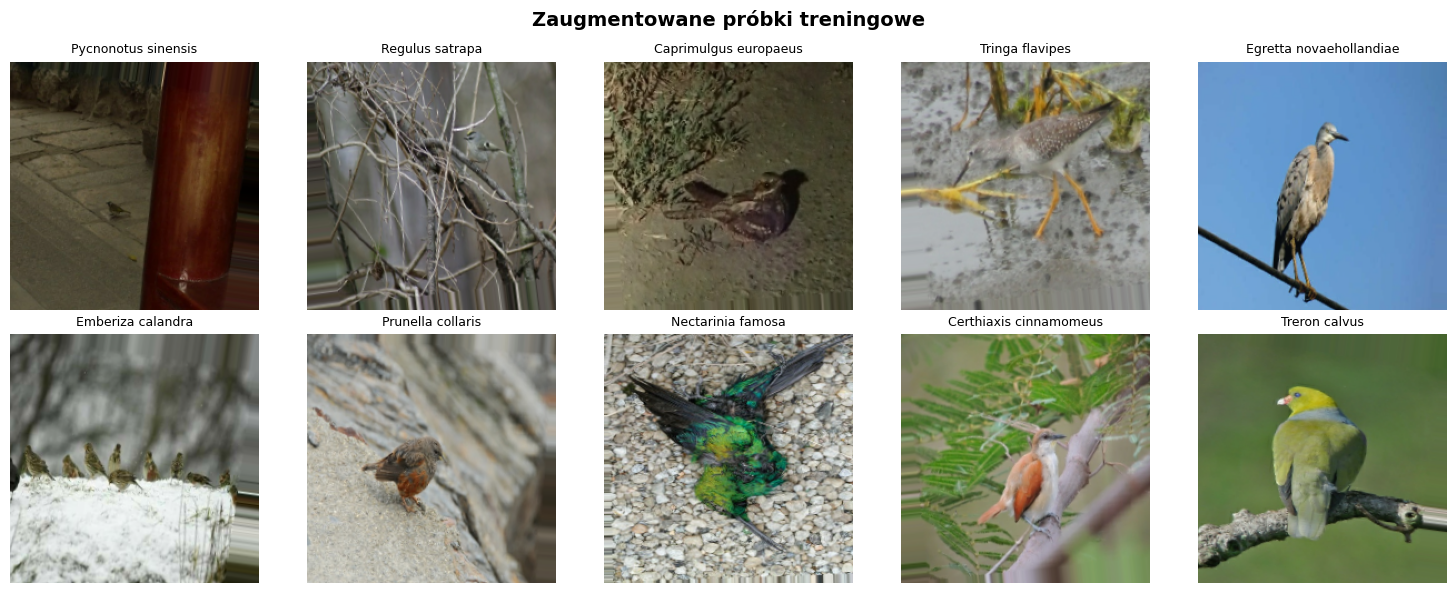

In [10]:
# Przykładowe zdjęcia treningowe po augmentacji
sample_batch = next(iter(train_ds))
images, labels = sample_batch

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
for i in range(5):
    axes[0, i].imshow(images[i].numpy().astype(np.uint8))
    axes[0, i].set_title(species_map[int(labels[i])], fontsize=9)
    axes[0, i].axis("off")

    axes[1, i].imshow(images[i + 5].numpy().astype(np.uint8))
    axes[1, i].set_title(species_map[int(labels[i + 5])], fontsize=9)
    axes[1, i].axis("off")

plt.suptitle("Zaugmentowane próbki treningowe", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

## 4. Budowa Modelu

**Architektura:** EfficientNetB0 (wytrenowany na ImageNet) + głowa klasyfikatora

```
Wejście (224x224x3)
  -> EfficientNetB0 (zamrożony szkielet)
  -> GlobalAveragePooling2D
  -> BatchNormalization
  -> Dropout(0.3)
  -> Dense(512, relu)
  -> Dropout(0.3)
  -> Dense(1486)  # surowe logity
```

In [11]:
# Wczytanie szkieletu EfficientNetB0 (wytrenowanego na ImageNet)
base_model = tf.keras.applications.EfficientNetB0(
    include_top=False,
    weights="imagenet",
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
)
base_model.trainable = False  # Zamrożenie na Fazę 1

# Budowa klasyfikatora na szczycie szkieletu
inputs = tf.keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
x = base_model(inputs, training=False)
x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = tf.keras.layers.BatchNormalization()(x)
x = tf.keras.layers.Dropout(0.3)(x)
x = tf.keras.layers.Dense(512, activation="relu")(x)
x = tf.keras.layers.Dropout(0.3)(x)
outputs = tf.keras.layers.Dense(num_classes)(x)  # surowe logity

model = tf.keras.Model(inputs, outputs, name="klasyfikator_ptakow")
model.summary()

Model: "klasyfikator_ptakow"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │       655,872 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1486)           │       762,318 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,472,881 (20.88 MB)

 Trainable params: 1,420,750 (5.42 MB)

 Non-trainable params: 4,052,131 (15.46 MB)

## 5. Definicja Funkcji Treningowych

In [12]:
loss_fn = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True)

# Metryki
train_loss = tf.keras.metrics.Mean(name="strata_treningowa")
train_acc = tf.keras.metrics.SparseCategoricalAccuracy(name="dokladnosc_treningowa")
val_loss_metric = tf.keras.metrics.Mean(name="strata_walidacyjna")
val_acc_metric = tf.keras.metrics.SparseCategoricalAccuracy(name="dokladnosc_walidacyjna")


@tf.function
def train_step(images, labels, optimizer):
    """Pojedynczy krok treningowy z tf.GradientTape."""
    with tf.GradientTape() as tape:
        logits = model(images, training=True)
        loss = loss_fn(labels, logits)
    gradients = tape.gradient(loss, model.trainable_variables)
    optimizer.apply_gradients(zip(gradients, model.trainable_variables))
    train_loss.update_state(loss)
    train_acc.update_state(labels, logits)


@tf.function
def val_step(images, labels):
    """Pojedynczy krok walidacyjny."""
    logits = model(images, training=False)
    loss = loss_fn(labels, logits)
    val_loss_metric.update_state(loss)
    val_acc_metric.update_state(labels, logits)


def run_epoch(dataset, optimizer=None, training=True):
    """Uruchamia jedną pełną epokę."""
    if training:
        train_loss.reset_state()
        train_acc.reset_state()
        for images, labels in dataset:
            train_step(images, labels, optimizer)
        return train_loss.result().numpy(), train_acc.result().numpy()
    else:
        val_loss_metric.reset_state()
        val_acc_metric.reset_state()
        for images, labels in dataset:
            val_step(images, labels)
        return val_loss_metric.result().numpy(), val_acc_metric.result().numpy()


print("Funkcje treningowe gotowe.")

Funkcje treningowe gotowe.


## 6. Faza 1 — Trenowanie Głowy Klasyfikatora

Szkielet EfficientNetB0 jest **zamrożony**. Trenowana jest tylko głowa klasyfikatora.

In [13]:
optimizer = tf.keras.optimizers.Adam(learning_rate=INITIAL_LR)
lr_var = optimizer.learning_rate

# Śledzenie historii
history = {
    "train_loss": [], "train_acc": [],
    "val_loss": [], "val_acc": [],
    "lr": [],
}

best_val_acc = 0.0
patience_counter = 0
phase1_epochs_done = 0

print("=" * 65)
print("Faza 1: Trenowanie głowy klasyfikatora (szkielet zamrożony)")
print("=" * 65)

for epoch in range(1, INITIAL_EPOCHS + 1):
    t_loss, t_acc = run_epoch(train_ds, optimizer, training=True)
    v_loss, v_acc = run_epoch(val_ds, training=False)

    history["train_loss"].append(t_loss)
    history["train_acc"].append(t_acc)
    history["val_loss"].append(v_loss)
    history["val_acc"].append(v_acc)
    history["lr"].append(float(lr_var))

    print(f"Epoka {epoch:2d}/{INITIAL_EPOCHS} | "
          f"strata: {t_loss:.4f}  dok.: {t_acc:.4f} | "
          f"val_strata: {v_loss:.4f}  val_dok.: {v_acc:.4f} | "
          f"lr: {float(lr_var):.2e}")

    if v_acc > best_val_acc:
        best_val_acc = v_acc
        patience_counter = 0
        ckpt = tf.train.Checkpoint(model=model, optimizer=optimizer)
        ckpt.write(os.path.join(CHECKPOINT_DIR, "faza1_najlepsza"))
    else:
        patience_counter += 1
        if patience_counter >= 2:
            new_lr = max(float(lr_var) * 0.5, 1e-6)
            lr_var.assign(new_lr)
            print(f"  -> Zmniejszenie lr: {new_lr:.2e}")
        if patience_counter >= 3:
            print("  -> Wczesne zatrzymanie")
            ckpt = tf.train.Checkpoint(model=model, optimizer=optimizer)
            ckpt.read(os.path.join(CHECKPOINT_DIR, "faza1_najlepsza"))
            break

    phase1_epochs_done = epoch

print(f"\nFaza 1 zakończona. Najlepsza dok. walidacyjna: {best_val_acc:.4f}")

Faza 1: Trenowanie głowy klasyfikatora (szkielet zamrożony)


E0000 00:00:1771621856.343766 1542908 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inklasyfikator_ptakow_1/efficientnetb0_1/block2b_drop_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer
2026-02-20 22:10:57.714709: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91900
2026-02-20 22:16:05.514136: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2026-02-20 22:17:17.696032: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


Epoka  1/10 | strata: 5.4590  dok.: 0.0842 | val_strata: 4.0561  val_dok.: 0.1996 | lr: 1.00e-03


2026-02-20 22:23:44.694088: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


Epoka  2/10 | strata: 4.5635  dok.: 0.1523 | val_strata: 3.7622  val_dok.: 0.2452 | lr: 1.00e-03
Epoka  3/10 | strata: 4.2442  dok.: 0.1882 | val_strata: 3.5740  val_dok.: 0.2718 | lr: 1.00e-03


2026-02-20 22:37:35.864558: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


Epoka  4/10 | strata: 3.9973  dok.: 0.2178 | val_strata: 3.4496  val_dok.: 0.2922 | lr: 1.00e-03
Epoka  5/10 | strata: 3.8351  dok.: 0.2355 | val_strata: 3.3786  val_dok.: 0.3022 | lr: 1.00e-03
Epoka  6/10 | strata: 3.7325  dok.: 0.2494 | val_strata: 3.3333  val_dok.: 0.3153 | lr: 1.00e-03
Epoka  7/10 | strata: 3.6566  dok.: 0.2611 | val_strata: 3.3096  val_dok.: 0.3168 | lr: 1.00e-03


2026-02-20 23:03:29.115795: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


Epoka  8/10 | strata: 3.6057  dok.: 0.2685 | val_strata: 3.2953  val_dok.: 0.3217 | lr: 1.00e-03
Epoka  9/10 | strata: 3.5730  dok.: 0.2719 | val_strata: 3.2817  val_dok.: 0.3244 | lr: 1.00e-03
Epoka 10/10 | strata: 3.5478  dok.: 0.2763 | val_strata: 3.2778  val_dok.: 0.3274 | lr: 1.00e-03

Faza 1 zakończona. Najlepsza dok. walidacyjna: 0.3274


## 7. Faza 2 — Dostrajanie Górnych Warstw EfficientNetB0

Odblokowanie górnych ~30% warstw EfficientNetB0 i trenowanie z dużo niższym współczynnikiem uczenia.

In [ ]:
# Odblokowanie górnych 30% warstw szkieletu
base_model.trainable = True
fine_tune_from = int(len(base_model.layers) * 0.7)
for layer in base_model.layers[:fine_tune_from]:
    layer.trainable = False

trainable = sum(1 for l in base_model.layers if l.trainable)
frozen = sum(1 for l in base_model.layers if not l.trainable)
print(f"Szkielet: {trainable} warstw trenowalnych, {frozen} zamrożonych")
print(f"Łączna liczba parametrów trenowalnych: {sum(tf.size(v).numpy() for v in model.trainable_variables):,}")

In [1]:
# Przedefiniowanie funkcji treningowych — tf.function musi odtworzyć ślad
# z nowym zestawem trenowalnych zmiennych (odblokowane warstwy)
@tf.function
def train_step_ft(images, labels, optimizer):
    """Pojedynczy krok treningowy dla fazy dostrajania."""
    with tf.GradientTape() as tape:
        logits = model(images, training=True)
        loss = loss_fn(labels, logits)
    gradients = tape.gradient(loss, model.trainable_variables)
    optimizer.apply_gradients(zip(gradients, model.trainable_variables))
    train_loss.update_state(loss)
    train_acc.update_state(labels, logits)


@tf.function
def val_step_ft(images, labels):
    """Pojedynczy krok walidacyjny dla fazy dostrajania."""
    logits = model(images, training=False)
    loss = loss_fn(labels, logits)
    val_loss_metric.update_state(loss)
    val_acc_metric.update_state(labels, logits)


def run_epoch_ft(dataset, optimizer=None, training=True):
    """Uruchamia jedną pełną epokę (wersja dostrajania)."""
    if training:
        train_loss.reset_state()
        train_acc.reset_state()
        for images, labels in dataset:
            train_step_ft(images, labels, optimizer)
        return train_loss.result().numpy(), train_acc.result().numpy()
    else:
        val_loss_metric.reset_state()
        val_acc_metric.reset_state()
        for images, labels in dataset:
            val_step_ft(images, labels)
        return val_loss_metric.result().numpy(), val_acc_metric.result().numpy()


optimizer_ft = tf.keras.optimizers.Adam(learning_rate=FINE_TUNE_LR)
lr_var_ft = optimizer_ft.learning_rate

patience_counter = 0

print("=" * 65)
print("Faza 2: Dostrajanie górnych warstw EfficientNetB0")
print("=" * 65)

for epoch in range(1, FINE_TUNE_EPOCHS + 1):
    global_epoch = phase1_epochs_done + epoch

    t_loss, t_acc = run_epoch_ft(train_ds, optimizer_ft, training=True)
    v_loss, v_acc = run_epoch_ft(val_ds, training=False)

    history["train_loss"].append(t_loss)
    history["train_acc"].append(t_acc)
    history["val_loss"].append(v_loss)
    history["val_acc"].append(v_acc)
    history["lr"].append(float(lr_var_ft))

    print(f"Epoka {global_epoch:2d}/{phase1_epochs_done + FINE_TUNE_EPOCHS} | "
          f"strata: {t_loss:.4f}  dok.: {t_acc:.4f} | "
          f"val_strata: {v_loss:.4f}  val_dok.: {v_acc:.4f} | "
          f"lr: {float(lr_var_ft):.2e}")

    if v_acc > best_val_acc:
        best_val_acc = v_acc
        patience_counter = 0
        ckpt = tf.train.Checkpoint(model=model, optimizer=optimizer_ft)
        ckpt.write(os.path.join(CHECKPOINT_DIR, "faza2_najlepsza"))
        print(f"  -> Zapisano najlepszy checkpoint (val_dok.: {v_acc:.4f})")
    else:
        patience_counter += 1
        if patience_counter >= 2:
            new_lr = max(float(lr_var_ft) * 0.5, 1e-7)
            lr_var_ft.assign(new_lr)
            print(f"  -> Zmniejszenie lr: {new_lr:.2e}")
        if patience_counter >= 5:
            print("  -> Wczesne zatrzymanie")
            ckpt = tf.train.Checkpoint(model=model, optimizer=optimizer_ft)
            ckpt.read(os.path.join(CHECKPOINT_DIR, "faza2_najlepsza"))
            break

print(f"\nTrenowanie zakończone! Najlepsza dok. walidacyjna: {best_val_acc:.4f}")

NameError: name 'tf' is not defined

## 8. Zapis Modelu

In [ ]:
# Zapis modelu w formacie Keras (tf.saved_model.save ma błąd w TF 2.20)
KERAS_MODEL_PATH = os.path.join(os.getcwd(), "bird_model.keras")
model.save(KERAS_MODEL_PATH)
print(f"Model zapisano do: {KERAS_MODEL_PATH}")

## 9. Wizualizacja Historii Trenowania

In [ ]:
epochs_range = range(1, len(history["train_loss"]) + 1)
phase1_end = phase1_epochs_done

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Strata
axes[0].plot(epochs_range, history["train_loss"], "b-o", markersize=4, label="Strata treningowa")
axes[0].plot(epochs_range, history["val_loss"], "r-o", markersize=4, label="Strata walidacyjna")
axes[0].axvline(x=phase1_end, color="gray", linestyle="--", alpha=0.7, label="Początek dostrajania")
axes[0].set_xlabel("Epoka")
axes[0].set_ylabel("Strata")
axes[0].set_title("Strata")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Dokładność
axes[1].plot(epochs_range, history["train_acc"], "b-o", markersize=4, label="Dok. treningowa")
axes[1].plot(epochs_range, history["val_acc"], "r-o", markersize=4, label="Dok. walidacyjna")
axes[1].axvline(x=phase1_end, color="gray", linestyle="--", alpha=0.7, label="Początek dostrajania")
axes[1].set_xlabel("Epoka")
axes[1].set_ylabel("Dokładność")
axes[1].set_title("Dokładność")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Współczynnik uczenia
axes[2].plot(epochs_range, history["lr"], "g-o", markersize=4)
axes[2].axvline(x=phase1_end, color="gray", linestyle="--", alpha=0.7, label="Początek dostrajania")
axes[2].set_xlabel("Epoka")
axes[2].set_ylabel("Współczynnik uczenia")
axes[2].set_title("Harmonogram współczynnika uczenia")
axes[2].set_yscale("log")
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.suptitle("Historia trenowania", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

## 10. Predykcja na Pojedynczych Zdjęciach

In [ ]:
def predict_image(image_path, top_k=5):
    """Przewiduje gatunek ptaka dla pojedynczego zdjęcia."""
    # Wczytanie i przetwarzanie
    raw = tf.io.read_file(image_path)
    image = tf.image.decode_jpeg(raw, channels=3)
    image_display = image.numpy()  # oryginał do wyświetlenia
    image = tf.image.resize(image, [IMG_SIZE, IMG_SIZE])
    image = tf.cast(image, tf.float32)
    image = tf.expand_dims(image, 0)

    # Przejście w przód przez model
    logits = model(image, training=False)
    probs = tf.nn.softmax(logits, axis=-1).numpy()[0]
    top_indices = probs.argsort()[-top_k:][::-1]

    # Wyświetlenie wyników
    fig, axes = plt.subplots(1, 2, figsize=(12, 5),
                             gridspec_kw={"width_ratios": [1, 1.5]})

    axes[0].imshow(image_display)
    axes[0].axis("off")
    axes[0].set_title("Zdjęcie wejściowe", fontsize=12)

    names = [species_map[int(i)] for i in top_indices]
    confs = [probs[i] * 100 for i in top_indices]
    colors = ["#2ecc71" if i == 0 else "#3498db" for i in range(top_k)]

    bars = axes[1].barh(range(top_k - 1, -1, -1), confs, color=colors)
    axes[1].set_yticks(range(top_k - 1, -1, -1))
    axes[1].set_yticklabels(names)
    axes[1].set_xlabel("Pewność (%)")
    axes[1].set_title("Najlepsze predykcje", fontsize=12)
    axes[1].set_xlim(0, max(confs) * 1.2)

    for bar, conf in zip(bars, confs):
        axes[1].text(bar.get_width() + 0.5, bar.get_y() + bar.get_height() / 2,
                     f"{conf:.1f}%", va="center", fontsize=10)

    plt.tight_layout()
    plt.show()

    return {names[i]: f"{confs[i]:.2f}%" for i in range(top_k)}


print("Funkcja predict_image() gotowa.")

In [ ]:
# Test predykcji na losowym zdjęciu walidacyjnym
random_idx = np.random.randint(0, len(val_paths))
test_image_path = val_paths[random_idx].numpy().decode("utf-8")
print(f"Test na: {os.path.basename(os.path.dirname(test_image_path))}")

results = predict_image(test_image_path, top_k=5)

## 11. Ewaluacja na Zbiorze Walidacyjnym

In [ ]:
# Pełna ewaluacja na zbiorze walidacyjnym
val_loss_metric.reset_state()
val_acc_metric.reset_state()

# Śledzenie dokładności Top-5
top5_correct = 0
total_samples = 0

for images, labels in val_ds:
    logits = model(images, training=False)
    loss = loss_fn(labels, logits)
    val_loss_metric.update_state(loss)
    val_acc_metric.update_state(labels, logits)

    # Top-5
    top5_preds = tf.math.top_k(logits, k=5).indices
    labels_expanded = tf.expand_dims(labels, 1)
    top5_correct += tf.reduce_sum(
        tf.cast(tf.reduce_any(tf.equal(top5_preds, labels_expanded), axis=1), tf.int32)
    ).numpy()
    total_samples += len(labels)

final_val_loss = val_loss_metric.result().numpy()
final_val_acc = val_acc_metric.result().numpy()
top5_acc = top5_correct / total_samples

print(f"Strata walidacyjna:       {final_val_loss:.4f}")
print(f"Dokładność walidacyjna:   {final_val_acc:.4f} (Top-1)")
print(f"Dokładność Top-5:         {top5_acc:.4f}")
print(f"Łączna liczba próbek:     {total_samples:,}")

## 12. Predykcja na Własnym Zdjęciu

Zmień `SCIEZKA_ZDJECIA` poniżej, aby przetestować dowolne zdjęcie ptaka.

In [ ]:
# Zmień tę ścieżkę na własne zdjęcie ptaka
SCIEZKA_ZDJECIA = "sciezka/do/twojego/zdjecia_ptaka.jpg"

if os.path.exists(SCIEZKA_ZDJECIA):
    results = predict_image(SCIEZKA_ZDJECIA, top_k=5)
else:
    print(f"Plik nie znaleziony: {SCIEZKA_ZDJECIA}")
    print("Zaktualizuj SCIEZKA_ZDJECIA, aby wskazywała na prawdziwe zdjęcie ptaka.")